<a href="https://colab.research.google.com/github/PalQuisp/Sis420-int/blob/main/lab003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio de programación Regresión Polinomial

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

## 2 Regresión polinomica

Se implementa la regresion polinomial para predecir el la capacidad adquisitiva de una persona. El archivo `Datasets/capacidad_adquisitiva.csv` contiene un dataset para entrenamiento de capacidad adquisitiva de las personas considerando la edad de las personas de la ciudad de Sucre. La primera columna es la edad y la segunda columna es la capacidad adquisitiva en bolivianos por mes.

<a id="section4"></a>
### 2.1 Normalización de caracteristicas

Al visualizar los datos se puede observar que las caracteristicas tienen diferentes magnitudes, por lo cual se debe transformar cada valor en una escala de valores similares, esto con el fin de que el descenso por el gradiente pueda converger mas rapidamente.

In [ ]:
import numpy as np
import re # Importar la librería de expresiones regulares

# Converter for purchasing power (column 0 in CSV)
def purchasing_power_converter(s):
    s_str = s.strip()
    if not s_str:
        return np.nan
    try:
        # Assumes format like 1.172.470,00 (dots for thousands, comma for decimal)
        return float(s_str.replace('.', '').replace(',', '.'))
    except ValueError:
        return np.nan

# Converter for age (column 1 in CSV)
def age_converter(s):
    s_str = s.strip()
    if not s_str:
        return np.nan
    # Extract only digits for age
    numeric_parts = re.findall(r'\d+', s_str) # Corrected regex
    if numeric_parts:
        try:
            return float("".join(numeric_parts)) # Join digits if scattered
        except ValueError:
            return np.nan
    return np.nan # No numeric parts found

# Apply these converters to the respective columns
converters = {0: purchasing_power_converter, 1: age_converter}

col0_raw_data, col1_raw_data = np.genfromtxt(
    '/content/gdrive/MyDrive/machine learning/datasets/lab002.csv',
    delimiter=";",
    skip_header=1,
    encoding='latin1',
    converters=converters,
    usecols=(0, 1),
    unpack=True
)

# Correct assignment based on actual data content
X_gd_raw = col1_raw_data.reshape(-1, 1) # X for gradient descent is age (from CSV column 1)
y_gd = col0_raw_data # y for gradient descent is purchasing power (from CSV column 0)

# Filter out rows with NaN values in either X_gd_raw or y_gd
valid_indices_gd = ~np.isnan(X_gd_raw).any(axis=1) & ~np.isnan(y_gd)
X_gd_raw = X_gd_raw[valid_indices_gd]
y_gd = y_gd[valid_indices_gd]
m_gd = y_gd.size # Update m_gd after filtering

# For initial plotting or inspection, use X_gd_raw and y_gd
for i in range(min(20, m_gd)): # Ensure not to go out of bounds if m_gd < 20
    print('{:8.0f}{:10.0f}'.format(X_gd_raw[i, 0], y_gd[i]))

       2       440
      42       550
       2    553850
       2   2694490
       3   1086940
       2   1085660
       2    218620
       2       340
    2077   1091500
       3    292030
       2     49520
       2    227300
       2       320
       2   1174180
    2042   1517290
       4   1222670
       7    251570
       1    433850
    1896    594650
       2       220


La desviación estándar es una forma de medir cuánta variación hay en el rango de valores de una característica en particular (la mayoría de los puntos caeran en un rango de ± 2 en relación a la desviaciones estándar de la media); esta es una alternativa a tomar el rango de valores (max-min). En `numpy`, se puede usar la función `std` para calcular la desviacion estandar.

Por ejemplo, la caracteristica`X[:, 0]` contiene todos los valores de $x_1$ (edades) en el conjunto de entrenamiento, entonces `np.std(X[:, 0])` calcula la desviacion estandar de las edades.
En el momento en que se llama a la función `featureNormalize`, la columna adicional de unos correspondiente a $ x_0 = 1 $ aún no se ha agregado a $ X $.

<div class="alert alert-block alert-warning">
**Notas para la implementación:** Cuando se normalize una caracteristica, es importante almacenar los valores usados para la normalización - el valor de la media y el valor de la desviación estandar usado para los calculos. Despues de aprender los parametros del modelo, se deseara predecir la capacidad adquisitiva que no se han visto antes. Dado un nuevo valor de x (edad), primero se debe normalizar x usando la media y la desviacion estandar que se empleo anteriormente en el conjunto de entrenamiento para entrenar el modelo.
</div>
<a id="featureNormalize"></a>

In [ ]:
def plotData(x, y):
    #Grafica los puntos x e y en una figura nueva.

    fig = pyplot.figure()  # abre una nueva figura

    pyplot.plot(x, y, 'ro', ms=10, mec='k')
    pyplot.xlabel('Edad personas') # Corrected label
    pyplot.ylabel('Capacidad adquisitiva 1,000s') # Corrected label


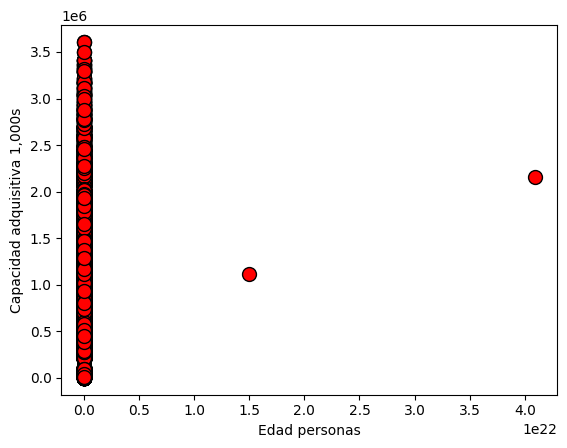

In [ ]:
plotData(X, y)

In [ ]:
# Create polynomial features for gradient descent
X_gd = np.concatenate([X_gd_raw, X_gd_raw * X_gd_raw], axis=1)

In [ ]:
print(X)

[[1.000000e+00 2.000000e+00 4.000000e+00]
 [1.000000e+00 4.200000e+01 1.764000e+03]
 [1.000000e+00 2.000000e+00 4.000000e+00]
 ...
 [1.000000e+00 2.000000e+00 4.000000e+00]
 [1.000000e+00 2.042000e+03 4.169764e+06]
 [1.000000e+00 2.000000e+00 4.000000e+00]]


In [ ]:
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [ ]:
# llama featureNormalize con los datos cargados
# X_gd here is (m_gd, 2) (age, age^2), without intercept yet
X_gd_norm, mu, sigma = featureNormalize(X_gd)

#print(X_gd_norm)
#print('Media calculada:', mu)
#print('Desviación estandar calculada:', sigma)
#print(X_gd_norm)

In [ ]:
print(X_norm)

[[-0.02581174]
 [-0.02581174]
 [-0.02581174]
 ...
 [-0.02581174]
 [-0.02581129]
 [-0.02581174]]


Despues de `featureNormalize` la funcion es provada, se añade el temino de interseccion a `X_norm`:

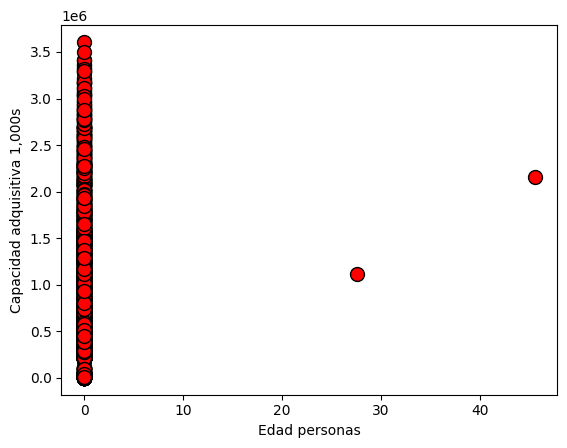

In [ ]:
plotData(X_gd_norm[:, 0], y_gd) # Use X_gd_norm[:, 0] for normalized age and y_gd for purchasing power


In [ ]:
# Añade el termino de interseccion a X_gd
# (Columna de unos para X0) - AFTER normalization
X_gd = np.concatenate([np.ones((m_gd, 1)), X_gd_norm], axis=1)

In [ ]:
print(X)

[[1.000000e+00 2.000000e+00 4.000000e+00]
 [1.000000e+00 4.200000e+01 1.764000e+03]
 [1.000000e+00 2.000000e+00 4.000000e+00]
 ...
 [1.000000e+00 2.000000e+00 4.000000e+00]
 [1.000000e+00 2.042000e+03 4.169764e+06]
 [1.000000e+00 2.000000e+00 4.000000e+00]]


<a id="section5"></a>
### 2.2 Descenso por el gradiente

En el ejemplo anterior se implemento el descenso por el gradiente para un problema de regresion univariable. La unica diferencia es que ahora existe una caracteristica adicional en la matriz $X$. La función de hipótesis y la regla de actualización del descenso del gradiente por lotes permanecen sin cambios.

La implementacion de las funciones `computeCostMulti` y `gradientDescentMulti` son similares a la funcion de costo y función de descenso por el gradiente de la regresión lineal multiple es similar al de la regresion lineal multivariable. Es importante garantizar que el codigo soporte cualquier numero de caracteristicas y esten bien vectorizadas.

Se puede utilizar `shape`, propiedad de los arrays `numpy`, para identificar cuantas caracteristicas estan consideradas en el dataset.

<div class="alert alert-block alert-warning">
**Nota de implementación:** En el caso de multivariables, la función de costo puede se escrita considerando la forma vectorizada de la siguiente manera:

$$ J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y}) $$

donde:

$$ X = \begin{pmatrix}
- (x^{(1)})^T - \\
- (x^{(2)})^T - \\
\vdots \\
- (x^{(m)})^T - \\ \\
\end{pmatrix} \qquad \mathbf{y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \\\end{bmatrix}$$

La version vectorizada es eficiente cuando se trabaja con herramientas de calculo numericos computacional como `numpy`.
</div>

<a id="computeCostMulti"></a>

In [ ]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [ ]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

#### 3.2.1 Seleccionando coheficientes de aprendizaje


theta calculado por el descenso por el gradiente: [978891.64139628 -21335.61099098  42412.65601155]
La capacidad adquisitiva para una persona de 33 (usando el descenso por el gradiente): $978420


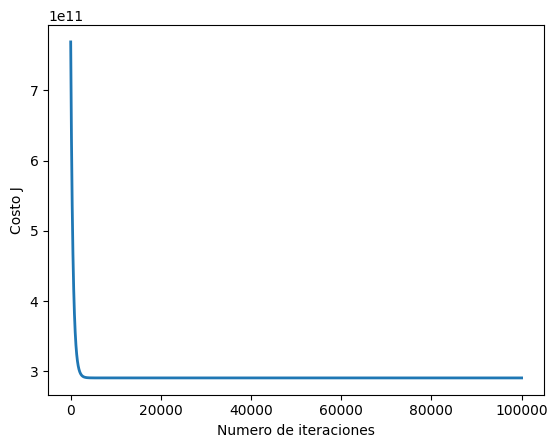

In [ ]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001
num_iters = 100000

# inicializa theta y ejecuta el descenso por el gradiente
theta_gd = np.zeros(X_gd.shape[1]) # Initialize theta based on X_gd columns (m_gd, 3)
theta_gd, J_history = gradientDescentMulti(X_gd, y_gd, theta_gd, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta_gd)))

# La capacidad adquisitiva de una persona de 33 años
# Need to apply the same feature transformations and normalization
age_val = 33
X_array = np.array([age_val, age_val**2]).reshape(1, -1) # Raw polynomial features
X_array_norm = (X_array - mu) / sigma # Normalize using mu and sigma from training
X_array_final = np.concatenate([np.ones((1, 1)), X_array_norm], axis=1)
price_gd = np.dot(X_array_final, theta_gd) # Use theta_gd

print('La capacidad adquisitiva para una persona de {} (usando el descenso por el gradiente): ${:.0f}'.format(age_val, price_gd[0]))

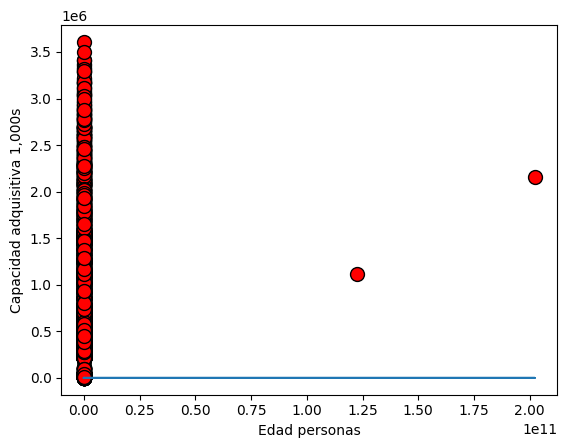

In [ ]:
plotData(X[:, 1], y)
pyplot.plot(X[:, 1], np.dot(X, theta), '-')

In [ ]:
X_array = [1, 23, 529]
X_array[1:3] = (X_array[1:3] - mu) / sigma

In [ ]:
X_array[1:3]
print(np.dot(X_array, theta))

0.0


<a id="section7"></a>
### 2.3 Ecuacion de la Normal

Una manera de calcular rapidamente el modelo de una regresion lineal es:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Utilizando esta formula no requiere que se escale ninguna caracteristica, y se obtendra una solucion exacta con un solo calculo: no hay “bucles de convergencia” como en el descenso por el gradiente.

Primero se recargan los datos para garantizar que las variables no esten modificadas. Recordar que no es necesario escalar las caracteristicas, se debe agregar la columna de unos a la matriz $X$ para tener el termino de intersección($\theta_0$).

In [ ]:
# Cargar datos para la Ecuación Normal
import numpy as np
import re # Importar la librería de expresiones regulares

# Converter for purchasing power (column 0 in CSV)
def purchasing_power_converter(s):
    s_str = s.strip()
    if not s_str:
        return np.nan
    try:
        # Assumes format like 1.172.470,00 (dots for thousands, comma for decimal)
        return float(s_str.replace('.', '').replace(',', '.'))
    except ValueError:
        return np.nan

# Converter for age (column 1 in CSV)
def age_converter(s):
    s_str = s.strip()
    if not s_str:
        return np.nan
    # Extract only digits for age
    numeric_parts = re.findall(r'\d+', s_str) # Corrected regex
    if numeric_parts:
        try:
            return float("".join(numeric_parts)) # Join digits if scattered
        except ValueError:
            return np.nan
    return np.nan # No numeric parts found

# Apply these converters to the respective columns
converters_ne = {0: purchasing_power_converter, 1: age_converter}

col0_raw_data_ne, col1_raw_data_ne = np.genfromtxt(
    '/content/gdrive/MyDrive/machine learning/datasets/lab002.csv',
    delimiter=";",
    skip_header=1,
    encoding='latin1',
    converters=converters_ne,
    usecols=(0, 1),
    unpack=True
)

# Correct assignment based on actual data content for normal equation
X_ne_raw = col1_raw_data_ne.reshape(-1, 1) # X_ne is age (from CSV column 1)
y_ne = col0_raw_data_ne # y_ne is purchasing power (from CSV column 0)

# Filter out rows with NaN values in either X_ne_raw or y_ne
valid_indices_ne = ~np.isnan(X_ne_raw).any(axis=1) & ~np.isnan(y_ne)
X_ne_raw = X_ne_raw[valid_indices_ne]
y_ne = y_ne[valid_indices_ne]
m_ne = y_ne.size # Update m_ne after filtering

# Build X_ne for normal equation with polynomial features and intercept
X_ne = np.concatenate([np.ones((m_ne, 1)), X_ne_raw, X_ne_raw * X_ne_raw], axis=1)

# Assign global X and y for normalEqn calls
X = X_ne
y = y_ne

In [ ]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [ ]:
# Calcula los parametros con la ecuación de la normal
theta_ne = normalEqn(X, y); # Use global X and y

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta_ne)));

# Estimar el precio para una persona de 33 años
# X is already in the correct format [1, age, age^2] for normal equation
age_val = 33
X_array_ne = np.array([1, age_val, age_val**2]).reshape(1, -1)
price_ne = np.dot(X_array_ne, theta_ne)

print('Capacidad adquisitiva para una edad de {} (usando la ecuación de la normal): ${:.0f}'.format(age_val, price_ne[0]))

Theta calculado a partir de la ecuación de la normal: [ 9.78430150e+05 -6.13576888e-06  5.90795539e-17]
Capacidad adquisitiva para una edad de 33 (usando la ecuación de la normal): $978430


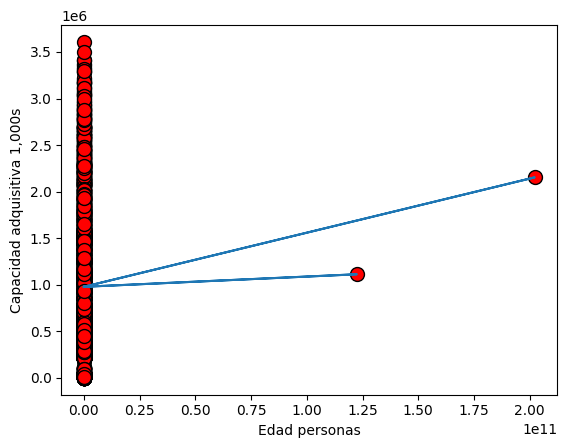

In [ ]:
plotData(X[:, 1], y)
pyplot.plot(X[:, 1], np.dot(X, theta_ne), '-')